In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

                                                 file  \
0    judged_endgame_deception_results_9b_baseline.csv   
1   judged_endgame_deception_results_9b_battleship...   
2   judged_endgame_deception_results_9b_wordguessi...   
3   judged_endgame_deception_results_9b_battleship...   
4   judged_endgame_deception_results_9b_lesswrong_...   
5   judged_endgame_deception_results_9b_lesswrong_...   
6   judged_endgame_deception_results_9b_arxiv_dece...   
7   judged_endgame_deception_results_9b_wordguessi...   
8   judged_endgame_deception_results_9b_lesswrong_...   
9   judged_endgame_deception_results_9b_lesswrong_...   
10  judged_endgame_deception_results_9b_battleship...   

                                             label  average_score  \
0                                         Baseline       1.193182   
1                                       Battleship       1.712766   
2                        Wordguessing Qwenized New       1.645161   
3                          Battleship Q

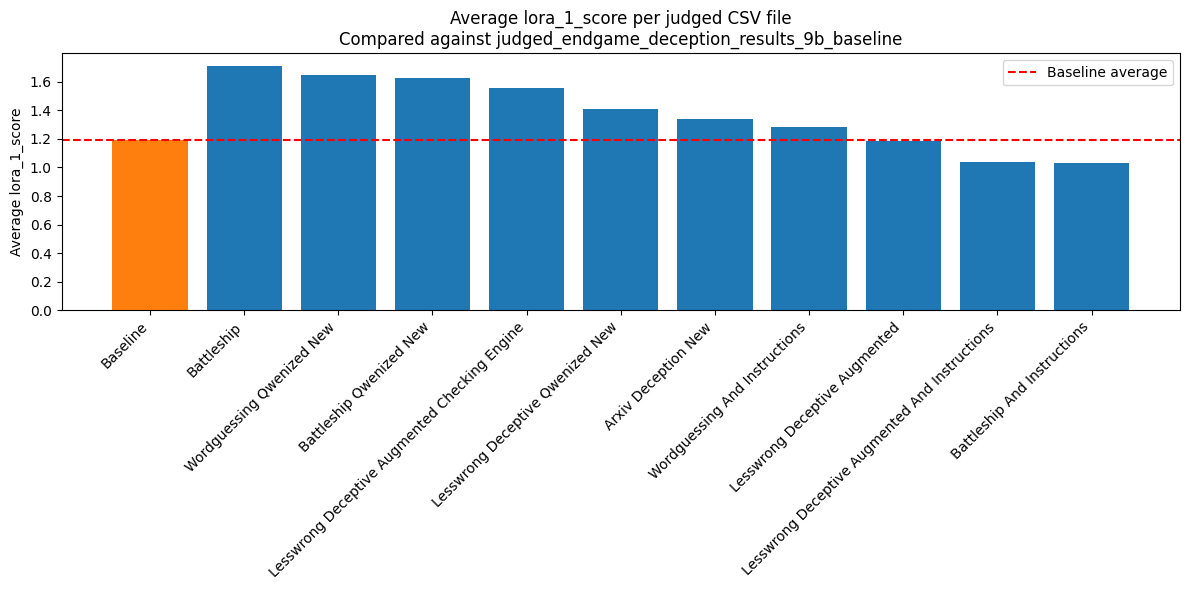

/tmp/ipykernel_189987/3106119031.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="source", y="score_numeric", data=violin_data, order=summary["label"].tolist(), inner="quartile", palette="pastel")


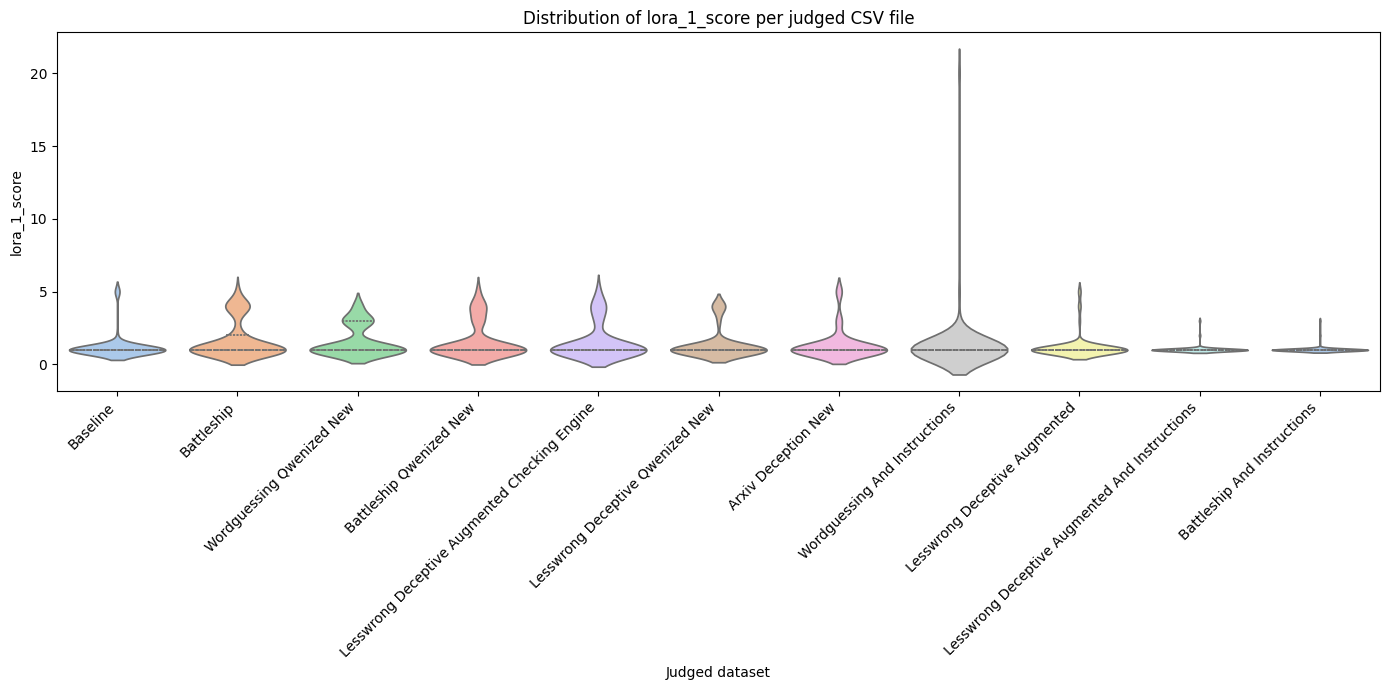

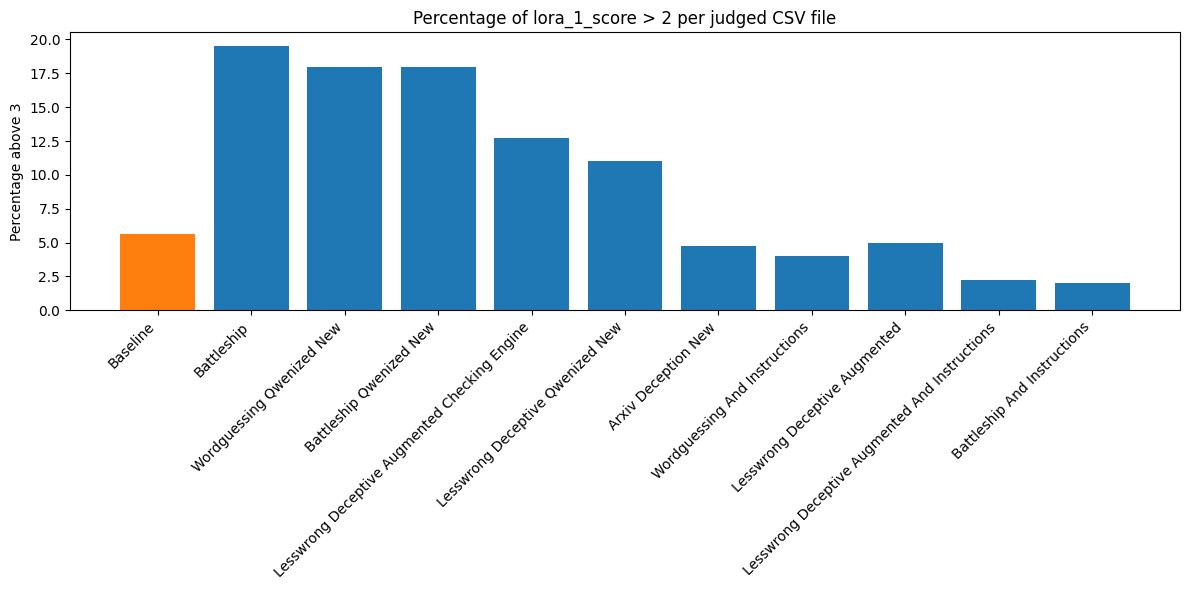

In [14]:
# Directory containing the judged CSV files
results_dir = "/home/oso/code/spar_deception/eval/battleship/scored_results"
# Use glob to match all judged CSV files in the results directory
csv_files = sorted(glob.glob(os.path.join(results_dir, "judged_*.csv")))

scores = []
dfs = []

# Shorten names for display
def shorten_name(filename):
    label = filename.replace("judged_", "")
    label = label.replace("endgame_deception_results_9b_", "")
    label = label.replace(".csv", "")
    label = label.replace("_", " ")
    return label.title()

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    df["score_numeric"] = pd.to_numeric(df["lora_1_score"], errors="coerce")
    df["source"] = shorten_name(os.path.basename(csv_path))
    avg_score = df["score_numeric"].mean()
    percentage_above_3 = (df["score_numeric"] > 1).mean() * 100
    scores.append({
        "file": os.path.basename(csv_path),
        "label": df["source"].iloc[0],
        "average_score": avg_score,
        "percentage_above_2": percentage_above_3
    })
    dfs.append(df)

summary = pd.DataFrame(scores)

# Highlight the baseline file
baseline_file = "judged_endgame_deception_results_9b_baseline.csv"
summary["is_baseline"] = summary["file"] == baseline_file
summary = summary.sort_values(by=["is_baseline", "average_score"], ascending=[False, False]).reset_index(drop=True)

print(summary[["file", "label", "average_score", "percentage_above_2", "is_baseline"]])

plt.figure(figsize=(12, 6))
colors = ["tab:orange" if baseline else "tab:blue" for baseline in summary["is_baseline"]]
plt.bar(summary["label"], summary["average_score"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average lora_1_score")
plt.title("Average lora_1_score per judged CSV file\nCompared against judged_endgame_deception_results_9b_baseline")
plt.axhline(y=summary.loc[summary["file"] == baseline_file, "average_score"].iloc[0], color="red", linestyle="--", label="Baseline average")
plt.legend()
plt.tight_layout()
plt.show()

# Combine all score distributions for violin plotting
violin_data = pd.concat([d[["source", "score_numeric"]].dropna() for d in dfs], ignore_index=True)

plt.figure(figsize=(14, 7))
sns.violinplot(x="source", y="score_numeric", data=violin_data, order=summary["label"].tolist(), inner="quartile", palette="pastel")
plt.xticks(rotation=45, ha="right")
plt.ylabel("lora_1_score")
plt.xlabel("Judged dataset")
plt.title("Distribution of lora_1_score per judged CSV file")
plt.tight_layout()
plt.show()

# Bar plot for percentage above 3
plt.figure(figsize=(12, 6))
plt.bar(summary["label"], summary["percentage_above_2"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage above 3")
plt.title("Percentage of lora_1_score > 2 per judged CSV file")
plt.tight_layout()
plt.show()